# This is a Revision file for all the Algorithms focusing on:
```
✅ EDA
✅ Feature Engineering
✅ Train-Test Split
✅ Model Building
✅ Hyperparameter Tuning
✅ Model Evaluation
✅ New Predictions
```

# Linear Regression

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
df = pd.read_csv('data/HousePrediction.csv')

In [16]:
df.head()
df.info()
df.describe()
df.isnull().sum()
addres = pd.get_dummies(df["ADDRESS"])

<class 'pandas.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  str    
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  str    
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  str    
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 2.7 MB


MSE:  326166.25889326475
R2-Score:  0.40138384424535367
MAE: 133.59118815336586
0.40138384424535367


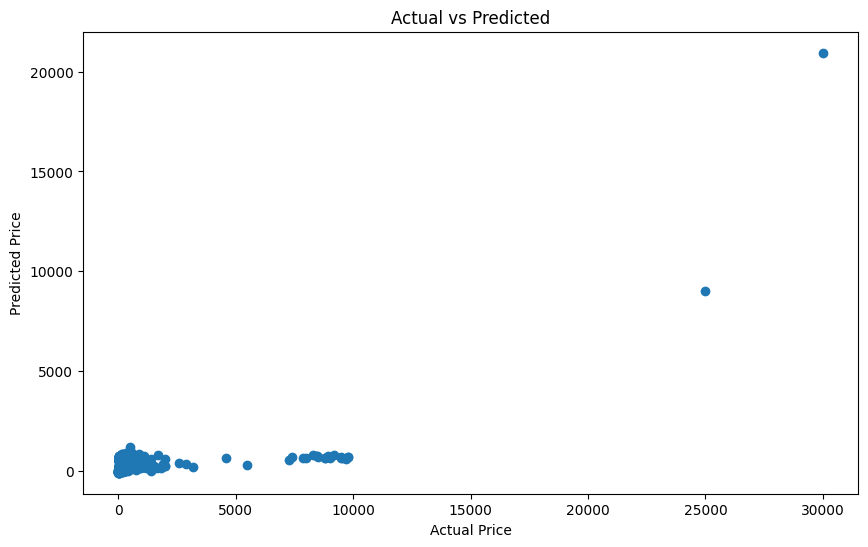

In [14]:
X = df[
    [
        "BHK_NO.",
        "SQUARE_FT",
        "RERA",
        "READY_TO_MOVE",
        "RESALE",
        "LATITUDE",
        "LONGITUDE"
    ]
]

Y = df['TARGET(PRICE_IN_LACS)']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print('MSE: ',mean_squared_error(y_test, y_pred))
print('R2-Score: ',r2_score(y_test, y_pred))
print('MAE:',mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

# Logistic Regression

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [18]:
df = pd.read_csv('data/Pass-Fail.csv')

In [20]:
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64

Accuracy:  1.0
Precision:  1.0
Recall:  1.0
F1:  1.0


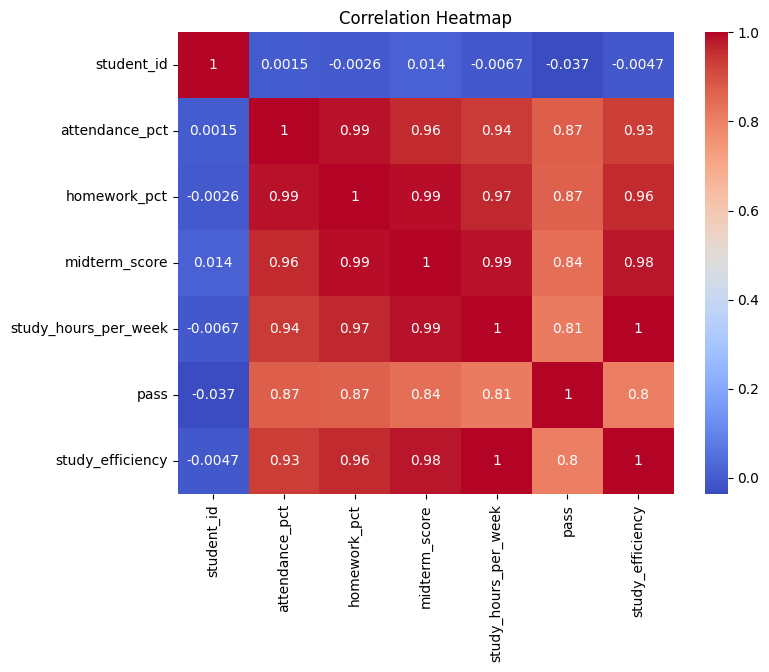

In [24]:
df['study_efficiency'] = df['study_hours_per_week']*df['attendance_pct']

X = df[['study_efficiency','homework_pct','midterm_score']]
Y = df['pass']

model = LogisticRegression()
model.fit(X, Y)

y_pred = model.predict(X)

print('Accuracy: ',accuracy_score(Y,y_pred))
print('Precision: ',precision_score(Y,y_pred))
print('Recall: ',recall_score(Y,y_pred))
print('F1: ',f1_score(Y,y_pred))

plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
new_student = [[600, 90, 85]]
print(model.predict(new_student))

[1]


C:\webdev-project\job-portal01\ai-service\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# NaiveBayes

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.feature_extraction.text import CountVectorizer

data = {
    "email_text": [
        "Win a free iPhone now",
        "Claim your cash prize today",
        "Meeting scheduled for tomorrow",
        "Project discussion at 3 PM",
        "Congratulations you won lottery",
        "Urgent! Claim your reward",
        "Can we reschedule our meeting",
        "Please find the attached report",
        "Free money waiting for you",
        "Let's have lunch tomorrow",
        "Get rich quick with this offer",
        "Team meeting starts at 10 AM",
        "Exclusive cash bonus available",
        "Monthly project status update",
        "Click here to win big rewards",
        "Reminder about your assignment",
        "Limited time free gift",
        "Client presentation on Monday",
        "Earn money from home easily",
        "Thank you for your email"
    ],

    "spam": [
        1, 1, 0, 0, 1,
        1, 0, 0, 1, 0,
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ]
}

df = pd.DataFrame(data)
vectorizer = CountVectorizer()

In [41]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   email_text  20 non-null     str  
 1   spam        20 non-null     int64
dtypes: int64(1), str(1)
memory usage: 448.0 bytes


email_text    0
spam          0
dtype: int64

In [44]:
X = df['email_text']
X_vector = vectorizer.fit_transform(df['email_text'])
Y = df['spam']

x_train, x_test, y_train, y_test = train_test_split(X_vector, Y, test_size=0.2, random_state=42)
model = MultinomialNB()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('F1: ',f1_score(y_test,y_pred))

x1 = ["Congratulations! You won 1 lakh rupees."]
x_1 = vectorizer.transform(x1)
print(model.predict(x_1))

Accuracy:  1.0
Precision:  1.0
Recall:  1.0
F1:  1.0
[1]


# KNN

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [46]:
df = pd.read_csv('data/loan_approval.csv')

In [47]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   str    
 1   city            2000 non-null   str    
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), str(2)
memory usage: 111.5 KB


name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

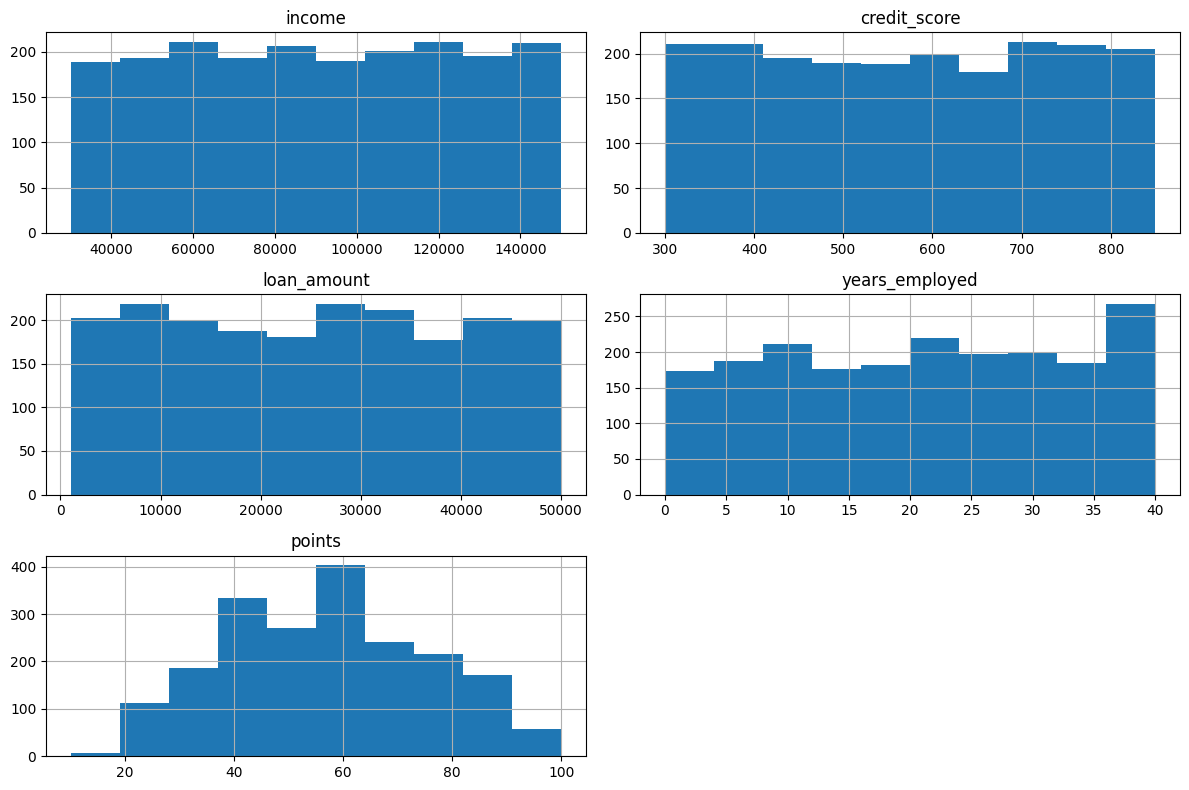

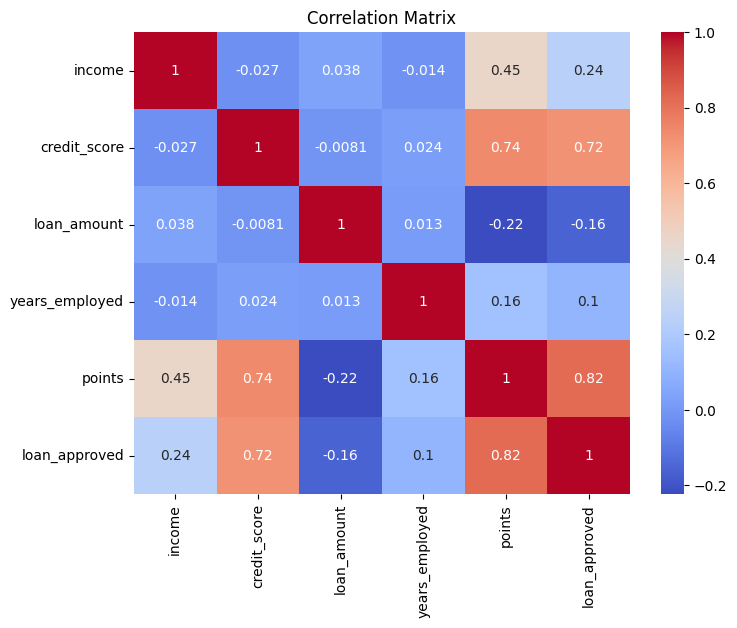

In [48]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = scaler.fit_transform(df[['income','credit_score','loan_amount','years_employed','points']])
Y = df['loan_approved']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy: ',accuracy_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('F1: ',f1_score(y_test,y_pred))

Accuracy:  0.9875
Precision:  0.978494623655914
Recall:  0.994535519125683
F1:  0.986449864498645


# Decision Tree

In [51]:
from sklearn.tree import DecisionTreeClassifier

data = {
    "fever":    [1,1,1,0,0,1,0,1,0,0,1,1,0,0,1,0,1,0,1,0,1,1,0,0,1],
    "cough":    [1,1,0,1,0,1,0,1,0,0,1,0,1,0,1,0,1,0,0,1,1,1,0,0,1],
    "headache": [1,0,1,1,0,1,0,1,0,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,1],
    "fatigue":  [1,1,1,0,0,1,0,1,0,0,1,1,0,0,1,0,1,0,1,0,1,1,0,0,1],
    "disease":  [1,1,1,0,0,1,0,1,0,0,1,1,0,0,1,0,1,0,1,0,1,1,0,0,1]
}

df = pd.DataFrame(data)

   fever  cough  headache  fatigue  disease
0      1      1         1        1        1
1      1      1         0        1        1
2      1      0         1        1        1
3      0      1         1        0        0
4      0      0         0        0        0


In [52]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   fever     25 non-null     int64
 1   cough     25 non-null     int64
 2   headache  25 non-null     int64
 3   fatigue   25 non-null     int64
 4   disease   25 non-null     int64
dtypes: int64(5)
memory usage: 1.1 KB


fever       0
cough       0
headache    0
fatigue     0
disease     0
dtype: int64

Accuracy:  1.0
Precision:  1.0
Recall:  1.0
F1:  1.0


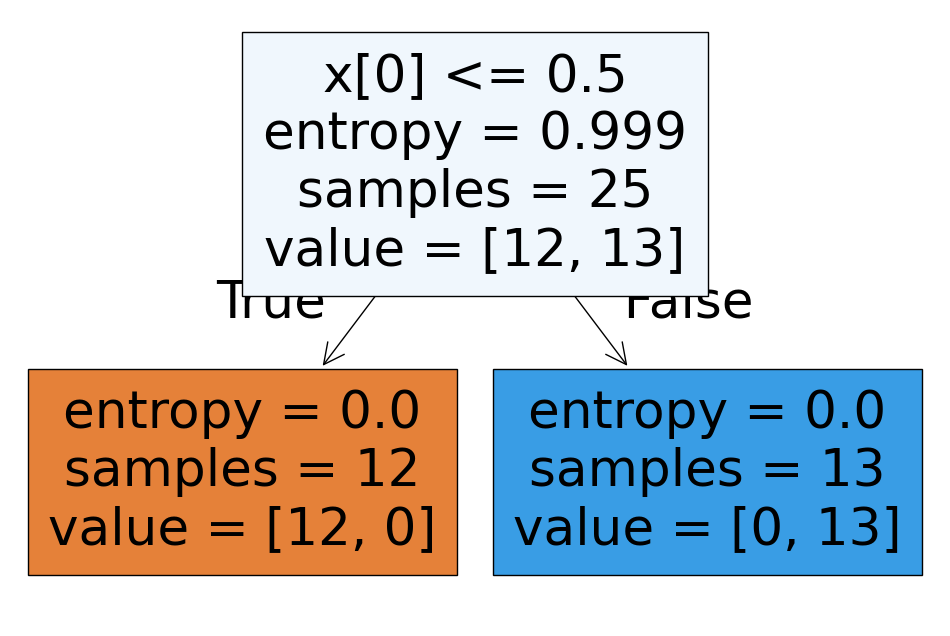

In [53]:
from sklearn import tree
X = df[['fever','cough','headache','fatigue']]
Y = df['disease']

classifier = DecisionTreeClassifier(criterion='entropy',max_depth=5)
classifier.fit(X,Y)

y_pred = classifier.predict(X)
print('Accuracy: ',accuracy_score(Y,y_pred))
print('Precision: ',precision_score(Y,y_pred))
print('Recall: ',recall_score(Y,y_pred))
print('F1: ',f1_score(Y,y_pred))

plt.figure(figsize=(12,8))
tree.plot_tree(classifier, filled=True)
plt.show()